## Классы nn.Linear и nn.Module

Для описания слоев НС с весами $W$ существует специальный модуль torch.nn.Linear. Давайте представим, что мы бы хотели описать работу уже знакомой нам НС с использованием класса nn.Linear. Смоделируем сеть, которая состоит из двух полносвязных слоев. Следовательно, нам необходимо сформировать два объекта следующими командами:

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

layer1 = nn.Linear(
    in_features =3, # in_features=3  указывает размер входного вектора
    out_features=2  # out_features=2 указывает размер выходного вектора
)
layer2 = nn.Linear(2, 1)

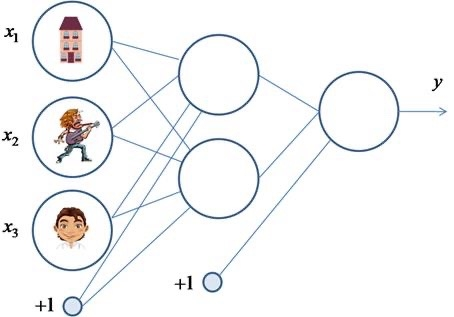

In [3]:
from IPython.display import Image

Image(filename='illustrations/nnLinear_1.jpg')

Следующим шагом объявляется функция с именем forward, которая будет пропускать через НС входной вектор inp:

In [4]:
def forward(inp, l1: nn.Linear, l2: nn.Linear):
    u1 = l1.forward(inp)
    s1 = F.tanh(u1)
 
    u2 = l2.forward(s1)
    s2 = F.tanh(u2)
    return s2

Каждый объект класса nn.Linear имеет метод forward, который вычисляет выходное значение по формуле:

$$
u_1 = W \cdot inp + b
$$

Но нужно полученный вектор $u_1$ еще пропустить через функцию активации. Выберем также гиперболический тангенс. Поэтому следом идет команда:

```
s1 = F.tanh(u1)
```

Это и есть вектор (тензор) выходных значений нейронов скрытого слоя.

Значения параметров можно посмотреть в следующих свойствах:

```
layer1.weight
layer2.weight
layer1.bias
layer2.bias
```

### 1. Пример

Давайте проверим, как будет работать функция ``forward``. Для этого текущие весовые коэффициенты объектов ``layer1`` и ``layer2``, а также их ``bias`` установим такими, которые были получены при обучении НС алгоритмом back propagation:

In [5]:
layer1.weight.data = torch.tensor([[0.7402,  0.6008, -1.3340], [0.2098,  0.4537, -0.7692]])
layer1.bias.data = torch.tensor([0.5505, 0.3719])
 
layer2.weight.data = torch.tensor([[-2.0719, -0.9485]])
layer2.bias.data = torch.tensor([-0.1461])

In [6]:
x = torch.FloatTensor([1, -1, 1])
y = forward(x, layer1, layer2)
print(y.data)

tensor([0.9165])


### 2. Класс nn.Module

Конечно, описывать работу всей НС или ее части через функции, не самый лучший подход. Гораздо удобнее использовать класс и в нем формировать всю необходимую логику. Тем более что фреймворк PyTorch предоставляет для этого специальный класс:

```
torch.nn.Module
```

То есть, мы можем создавать свои собственные модули нейронных сетей, которые будут на программном уровне работать, как единое целое. Давайте посмотрим, как это делается.

В самом простом варианте достаточно объявить свой собственный класс (например, с именем MyModule или каким-либо другим) унаследованный от базового класса ``nn.Module``, и внутри класса определить два метода:

In [7]:
class NetGirl(nn.Module):
    def __init__(self, input_dim, num_hidden, output_dim):
        """Инициализатор для формирования необходимых локальных переменных объекта модуля"""
        super().__init__() # вызов инициализатора базового класса
        # Создание и инициализация переменных модуля
        self.layer1 = nn.Linear(input_dim, num_hidden)
        self.layer2 = nn.Linear(num_hidden, output_dim)
 
    def forward(self, x):
        """Метод с реализацией прямого прохода переданного тензора x по НС"""
        x = self.layer1(x)
        x = F.tanh(x)
        x = self.layer2(x)
        x = F.tanh(x)
        return x # возврат тензора с выходными значениями нейронной сети

Давайте теперь посмотрим, что нам это дает. Во-первых, мы легко можем создавать двухслойные полносвязные НС с произвольным числом нейронов скрытого и выходного слоев. Например:

In [8]:
model  = NetGirl(3, 2, 1) # число входов 3; число нейронов 2 и 1
model1 = NetGirl(3, 5, 2) # число входов 3; число нейронов 5 и 2
model2 = NetGirl(100, 18, 10) # число входов 100; число нейронов 18 и 10

Чтобы просмотреть компоненты, содержащиеся в текущем модуле, достаточно вызвать функцию ``print``:

In [9]:
print(model)

NetGirl(
  (layer1): Linear(in_features=3, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
)


А для получения списка всех оптимизируемых параметров модели следует вызвать метод parameters:

In [10]:
gen_p = model.parameters() # возвращает генератор с набором параметров
print(list(model.parameters())) # отображение списка параметров

[Parameter containing:
tensor([[ 0.5608,  0.2983, -0.4603],
        [ 0.2509,  0.0718,  0.4569]], requires_grad=True), Parameter containing:
tensor([ 0.5398, -0.5761], requires_grad=True), Parameter containing:
tensor([[-0.6477,  0.1655]], requires_grad=True), Parameter containing:
tensor([-0.0848], requires_grad=True)]


### 3. Полный пример всей модели

Следующим шагом обучим НС model по уже знакомой нам выборке:

In [11]:
x_train = torch.FloatTensor([(-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1),
                            (1, -1, -1), (1, -1, 1), (1, 1, -1), (1, 1, 1)])
y_train = torch.FloatTensor([-1, 1, -1, 1, -1, 1, -1, -1])
total = len(y_train)

In [12]:
import torch.optim as optim
from random import randint

optimizer = optim.RMSprop(params=model.parameters(), lr=0.01) # оптимизатор RMSProp
loss_func = torch.nn.MSELoss() # квадратичная функция потерь

model.train() # переведем модель в режим обучения

for _ in range(1000):
    k = randint(0, total-1)
    y = model(x_train[k])
    loss = loss_func(y, y_train[k])
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

c:\Users\Evgen\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Мы здесь на каждой итерации выбираем случайный образ из выборки. И на его основе вычисляем потери и делаем коррекцию всех весовых коэффициентов НС по алгоритму back propagation. Причем, вначале нужно обнулить все градиенты, только после этого выполнить метод backward, а затем, метод step. Порядок вызова этих методов важен.

Инференс:

In [13]:
model.eval()

for x, d in zip(x_train, y_train):
    y = model(x)
    print(f"Выходное значение НС: {y.data} => {d}")

Выходное значение НС: tensor([-0.9911]) => -1.0
Выходное значение НС: tensor([0.9994]) => 1.0
Выходное значение НС: tensor([-0.9996]) => -1.0
Выходное значение НС: tensor([0.9913]) => 1.0
Выходное значение НС: tensor([-0.9996]) => -1.0
Выходное значение НС: tensor([0.9901]) => 1.0
Выходное значение НС: tensor([-0.9997]) => -1.0
Выходное значение НС: tensor([-0.9857]) => -1.0
